# M-PESA FRAUD DETECTION — MODELLING

This notebook covers the full modelling pipeline for the M-Pesa Fraud Detection project. The engineered dataset from the feature engineering notebook is loaded here and taken through preprocessing, model training, evaluation, and hyperparameter tuning.

## PIPELINE OVERVIEW

1. **Preprocessing** — encoding categorical features, feature scaling for Logistic Regression, train/test split
2. **Base Model Training** — four classifiers trained on consistent splits for fair comparison
3. **Evaluation** — each model evaluated on the holdout test split and the final unseen evaluation set
4. **Tuning** — best performing base model tuned using GridSearchCV and Optuna
5. **Final Evaluation** — tuned model evaluated against `evaluation.csv` — the final unseen dataset

---

## PREPROCESSING DECISIONS

### Categorical Encoding
Three categorical columns require encoding before modelling:

| Column | Unique Values | Encoding Strategy | Reason |
|---|---|---|---|
| `region` | 5 (Nairobi, Mombasa, Kisumu, Nakuru, Eldoret) | One-Hot Encoding | Nominal — no ordinal relationship between cities |
| `transaction_type` | 3 (peer, till, paybill) | One-Hot Encoding | Nominal — no ordinal relationship between types |
| `device_type` | 2 (smartphone, feature) | Binary Encoding (0/1) | Two categories — one-hot would produce perfectly inverse columns |

### Feature Scaling
Only **Logistic Regression** requires feature scaling. Tree-based models (Random Forest, XGBoost, LightGBM) make decisions based on feature split thresholds, not feature magnitude — scaling has no effect on their performance. Applying a `StandardScaler` to all models would be unnecessary overhead and adds no value beyond Logistic Regression.

### Class Imbalance
The dataset is heavily imbalanced — **97.07% legitimate vs 2.93% fraudulent** transactions. Two strategies are applied at different stages:

- **Base models:** `class_weight='balanced'` passed as a parameter to each classifier. This adjusts the loss function to penalise misclassification of the minority class (fraud) more heavily — a one-line adjustment that establishes a fair baseline without modifying the dataset.
- **Best model (post-selection):** SMOTE (Synthetic Minority Oversampling Technique) applied to the training data only, after the train/test split. SMOTE generates synthetic fraud samples by interpolating between existing fraud cases, giving the model more fraud patterns to learn from.

> **Important:** SMOTE is applied **after** splitting into train and test sets. Applying it before splitting would allow synthetic samples — generated from training data — to appear in the test set, producing artificially inflated evaluation metrics on data that is no longer truly unseen.

> **Synthetic-on-synthetic caveat:** Since the underlying dataset is itself synthetically generated, SMOTE interpolates between artificially placed fraud cases rather than real ones. This may amplify existing distributional artifacts in the data and inflate model confidence beyond what would be achievable on real M-Pesa transaction data. This limitation is documented in the model card.

---

## MODEL SELECTION

Four classifiers are compared in this notebook:

| Model | Scaling Required | Class Weight Support | Notes |
|---|---|---|---|
| Logistic Regression |  Yes |  `class_weight='balanced'` | Baseline model — linear decision boundary |
| Random Forest |  No |  `class_weight='balanced'` | Ensemble of decision trees — handles non-linear relationships |
| XGBoost |  No |  `scale_pos_weight` | Gradient boosting — strong on tabular data |
| LightGBM |  No |  `class_weight='balanced'` | Fast gradient boosting — efficient on large datasets |

All four models are trained on identical train/test splits to ensure fair comparison.

---

## EVALUATION METRICS

Given the class imbalance, **accuracy is not a meaningful metric** — a model predicting every transaction as legitimate would achieve 97% accuracy while catching zero fraud. The following metrics are used instead:

| Metric | Why It Matters Here |
|---|---|
| **Precision** | Of all transactions flagged as fraud, how many actually were? — minimises false alarms |
| **Recall** | Of all actual fraud cases, how many did the model catch? — minimises missed fraud |
| **F1 Score** | Harmonic mean of precision and recall — overall fraud detection performance |
| **AUC-ROC** | Model's ability to distinguish fraud from legitimate across all thresholds |

Recall is prioritised over precision in this context — a missed fraud transaction (false negative) causes direct financial loss to the customer, whereas a false alarm (false positive) causes friction but no monetary harm.

---

## TUNING STRATEGY

Hyperparameter tuning is applied to the **best performing base model only**. Tuning all four models is computationally expensive and unnecessary once a clear winner is identified.

Two tuning approaches are used sequentially:

1. **GridSearchCV** — exhaustive search over a defined parameter grid with cross-validation. Establishes a tuned baseline and refreshes understanding of the search process.
2. **Optuna (Bayesian Optimisation)** — probabilistic search that learns from previous trials to focus on promising parameter regions. More efficient than GridSearchCV on large parameter spaces. Results compared against GridSearchCV to quantify the efficiency gain.

---

## EVALUATION SETS

Each model is evaluated at two stages:

1. **Test split (20%)** — held out from `training.csv` during the 80-20 train/test split. Used for model comparison and selection.
2. **`evaluation.csv` (10,000 rows)** — completely unseen data carved out before any modelling began, with the original 97/3 class ratio preserved via stratification. Acts as the final real-world performance benchmark — no model decisions are made based on this set until the very end.

In [1]:
# LIBRARY IMPORTATION
# General
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector

#Classbalancing
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight

#Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

#Tunning and optimisation
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
import optuna

# Evaluation and coring
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                            f1_score, auc, roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Model saving
import joblib

In [2]:
# data Loading
df = pd.read_csv('../Data/training.csv')
eval_df = pd.read_csv('../Data/evaluation.csv')

print('TRAINING DATASET OVERVIEW')
print(f'='*100)
print(df.head())
print(f'='*100)
print('EVALAUTION DATASET OVERVIEW')
print(f'='*100)
print(eval_df.head())

TRAINING DATASET OVERVIEW
    amount  sender_balance_before transaction_type device_type   region  \
0   630.50               70062.43             till     feature   Nakuru   
1  2094.43               40608.35             till     feature   Nakuru   
2     9.25               61559.02          paybill     feature   Nakuru   
3  3124.94               51621.32             peer  smartphone  Mombasa   
4  2323.89               14156.01          paybill  smartphone  Nairobi   

   is_fraud  hour_sin  hour_cos       day_sin   day_cos  month_2026_sin  \
0         0 -0.500000 -0.866025 -2.449294e-16  1.000000        0.866025   
1         0  0.866025  0.500000  4.338837e-01 -0.900969        0.500000   
2         0 -0.707107 -0.707107  4.338837e-01 -0.900969        0.500000   
3         0  0.707107  0.707107 -7.818315e-01  0.623490        0.500000   
4         0 -0.500000  0.866025 -9.749279e-01 -0.222521       -0.866025   

   month_2026_cos  drain_rate  account_emptied  
0       -0.500000    0.

### LOGISTIC REGRESSOR

In [3]:
# Variable declaration
x = df.drop(columns=['is_fraud'])
y = df['is_fraud']

print(x.columns)

Index(['amount', 'sender_balance_before', 'transaction_type', 'device_type',
       'region', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'month_2026_sin', 'month_2026_cos', 'drain_rate', 'account_emptied'],
      dtype='str')


In [4]:
# Mapping deveice type to 1 or 0
x['device_type'] = x['device_type'].map({'smartphone': 0, 'feature': 1})
x['device_type'].value_counts()

device_type
1    55251
0    54664
Name: count, dtype: int64

In [5]:
# Using the ColumnTranformer for encoding
encoder = ColumnTransformer(
    transformers = [('cat', OneHotEncoder(), make_column_selector(dtype_include=['object', 'category']))]
)

x_encoded = encoder.fit_transform(x)
x_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 219830 stored elements and shape (109915, 8)>

In [6]:
# scaling the feature variables
scaler = StandardScaler(with_mean=False)
x_scaled = scaler.fit_transform(x_encoded)
x_scaled

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 219830 stored elements and shape (109915, 8)>

Train Prediction Summary Report
              precision    recall  f1-score   support

           0       0.97      0.53      0.69     85360
           1       0.03      0.49      0.06      2572

    accuracy                           0.53     87932
   macro avg       0.50      0.51      0.37     87932
weighted avg       0.94      0.53      0.67     87932

Test Prediction Summary Report
              precision    recall  f1-score   support

           0       0.97      0.53      0.68     21340
           1       0.03      0.47      0.05       643

    accuracy                           0.52     21983
   macro avg       0.50      0.50      0.37     21983
weighted avg       0.94      0.52      0.66     21983



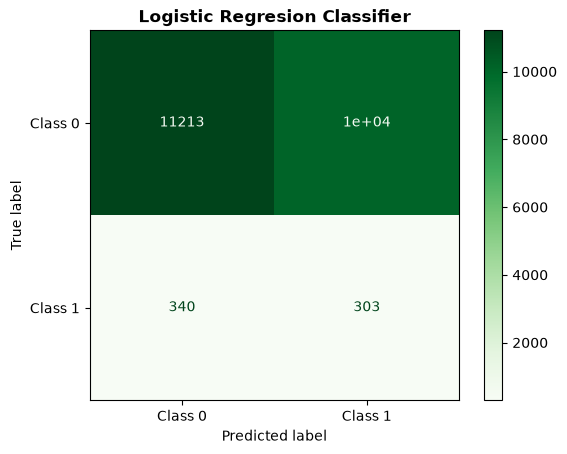

In [7]:
# Train test split 
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42,stratify=y)

#Model Initialization
log_classifier = LogisticRegression(class_weight='balanced', random_state=42)
log_classifier.fit(X_train, y_train)
# Predictions
y_train_pred = log_classifier.predict(X_train)
y_pred = log_classifier.predict(X_test)

# Evaluations
train_report = classification_report(y_train, y_train_pred)
test_report = classification_report(y_test, y_pred)
print('Train Prediction Summary Report')
print(f'='*100)
print(train_report)
print(f'='*100)
print('Test Prediction Summary Report')
print(f'='*100)
print(test_report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Logistic Regresion Classifier', weight = 'bold')
plt.show()

### RANDOM FOREST CLASSIFIER

RANDOM FOREST TRAIN PREDICTION SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.47      0.63     85360
           1       0.03      0.55      0.06      2572

    accuracy                           0.47     87932
   macro avg       0.50      0.51      0.34     87932
weighted avg       0.94      0.47      0.61     87932

RANDOM FOREST TEST PREDICTION SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.46      0.63     21340
           1       0.03      0.54      0.06       643

    accuracy                           0.47     21983
   macro avg       0.50      0.50      0.34     21983
weighted avg       0.94      0.47      0.61     21983



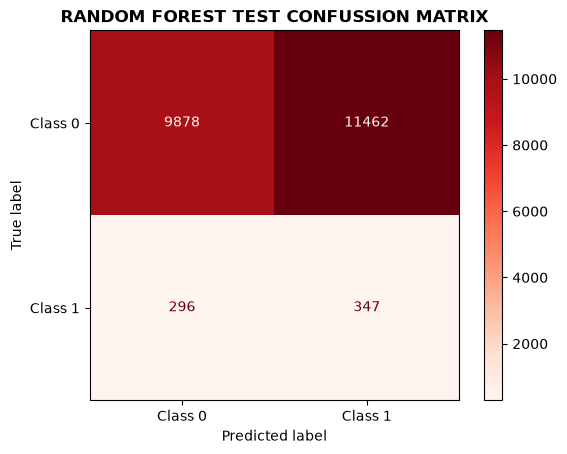

In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, random_state=42, stratify=y, test_size=0.2)



#Model initialization and fitting
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

#Predictions
train_preds = rf_model.predict(X_train)
test_preds = rf_model.predict(X_test)

#Evaluation
print('RANDOM FOREST TRAIN PREDICTION SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_train, train_preds))
print(f'='*100)
print('RANDOM FOREST TEST PREDICTION SUMMARY REPORT')
print(classification_report(y_test, test_preds))

#Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Reds)
plt.title('RANDOM FOREST TEST CONFUSSION MATRIX', weight = 'bold')
plt.show()

#### XGBOOST

XGBOOST TRAIN PREDICTIONS SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.40      0.57     85360
           1       0.03      0.62      0.06      2572

    accuracy                           0.41     87932
   macro avg       0.50      0.51      0.31     87932
weighted avg       0.94      0.41      0.55     87932

XGBOOST TEST PREDICTIONS SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.40      0.57     21340
           1       0.03      0.62      0.06       643

    accuracy                           0.41     21983
   macro avg       0.50      0.51      0.31     21983
weighted avg       0.94      0.41      0.55     21983



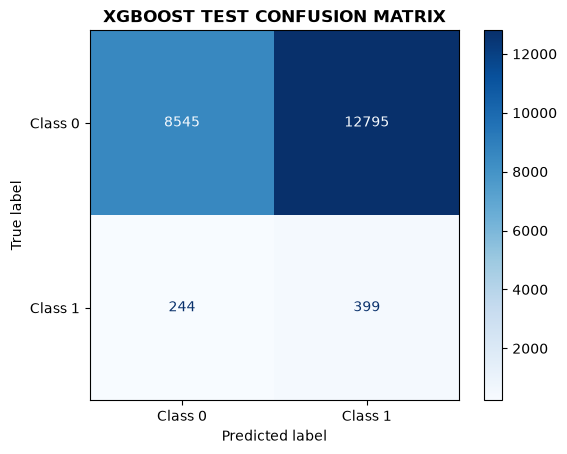

In [9]:
# Calculating classweights based on training labels
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Model Initialization and fitting
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train, sample_weight=sample_weights)

#Predictions
train_preds = xgb.predict(X_train)
test_preds = xgb.predict(X_test)

# Evaluations
print('XGBOOST TRAIN PREDICTIONS SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_train, train_preds))
print(f'='*100)
print('XGBOOST TEST PREDICTIONS SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_test, test_preds))

# Test Confussion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title('XGBOOST TEST CONFUSION MATRIX', weight='bold')
plt.show()

### LIGHTGBM

c:\Users\ngang\anaconda3\envs\mpesa-fraud\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ngang\anaconda3\envs\mpesa-fraud\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM TRAIN PREDICTIONS SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.40      0.57     85360
           1       0.03      0.62      0.06      2572

    accuracy                           0.41     87932
   macro avg       0.50      0.51      0.31     87932
weighted avg       0.94      0.41      0.55     87932

LGBM TEST PREDICTIONS SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.40      0.57     21340
           1       0.03      0.62      0.06       643

    accuracy                           0.41     21983
   macro avg       0.50      0.51      0.31     21983
weighted avg       0.94      0.41      0.55     21983



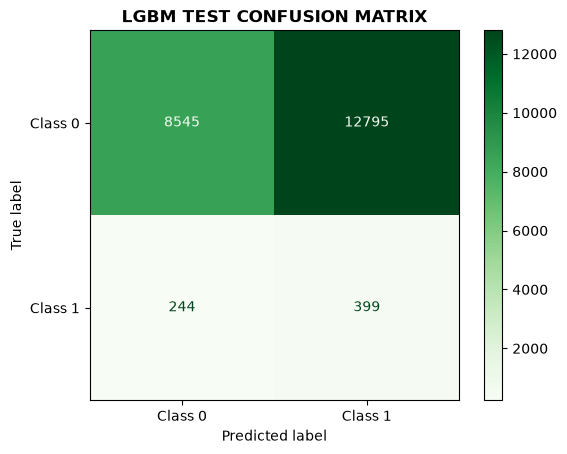

In [10]:
# Model initialization and fitting
lgb = LGBMClassifier(random_state=42, is_unbalance=True, verbose=-1)
lgb.fit(X_train, y_train)

#Predictions
train_preds = lgb.predict(X_train)
test_preds = lgb.predict(X_test)

#Evaluation
print('LGBM TRAIN PREDICTIONS SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_train, train_preds))
print(f'='*100)
print('LGBM TEST PREDICTIONS SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_test, test_preds))

# Test Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Greens)
plt.title('LGBM TEST CONFUSION MATRIX', weight = 'bold')
plt.show()

## BASE MODEL TRAINING & EVALUATION

Before tuning, four base classifiers were trained on identical train/test splits to establish a fair performance baseline. All models were trained on the same `X_train` and `X_test` splits with `random_state=42` and `stratify=y` to ensure consistency across comparisons.

### Class Imbalance Handling — Base Models
Each model handled the 97/3 class imbalance using its built-in weighting mechanism:

| Model | Imbalance Handling |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `compute_sample_weight(class_weight='balanced')` passed as `sample_weight` |
| LightGBM | `is_unbalance=True` |

---

### 1. Logistic Regression (Baseline)

Logistic Regression serves as the baseline model — the performance floor everything else is measured against.

**Results:**

| Split | Recall (Fraud) | Precision (Fraud) | F1 (Fraud) | Accuracy |
|---|---|---|---|---|
| Train | 0.49 | 0.03 | 0.06 | 0.53 |
| Test | 0.47 | 0.03 | 0.05 | 0.52 |

**Confusion Matrix (Test):**
- True Negatives: 11,213 — legitimate transactions correctly passed
- False Positives: 10,127 — legitimate transactions wrongly flagged
- False Negatives: 340 — fraud missed
- True Positives: 303 — fraud correctly caught

**Interpretation:**

The model catches 47% of fraud cases but generates 10,127 false positives against 303 true positives — a ratio of 33 false alarms for every fraud correctly caught. In a real M-Pesa setting this would mean 33 legitimate customers challenged or blocked for every fraudster stopped, which is not viable in production.

Train and test metrics are nearly identical, ruling out overfitting. The problem is the model's fundamental limitation — Logistic Regression learns a **linear decision boundary** and cannot capture the sharp non-linear threshold effect in `balance_drain_pct` (fraud rate jumps from ~1% below 50% drain to 100% above 100% drain). This is an architectural constraint, not a data fitting problem.

---

### 2. Random Forest

| Split | Recall (Fraud) | Precision (Fraud) | F1 (Fraud) | Accuracy |
|---|---|---|---|---|
| Train | 0.55 | 0.03 | 0.06 | 0.47 |
| Test | 0.54 | 0.03 | 0.06 | 0.47 |

**Interpretation:**

Random Forest improves recall marginally over Logistic Regression (0.54 vs 0.47) — the tree-based architecture handles non-linear relationships better. However precision remains at 0.03 and overall accuracy drops to 47%, meaning `class_weight='balanced'` is pushing the model to flag aggressively at the expense of legitimate transactions.

Train and test metrics are again nearly identical — no overfitting despite Random Forest's capacity for memorisation with default parameters. This consistency across two architecturally different models points to an upstream data limitation rather than a modelling problem.

---

### 3. XGBoost

| Split | Recall (Fraud) | Precision (Fraud) | F1 (Fraud) | Accuracy |
|---|---|---|---|---|
| Train | 0.62 | 0.03 | 0.06 | 0.41 |
| Test | 0.62 | 0.03 | 0.06 | 0.41 |

**Interpretation:**

XGBoost achieves the highest recall of the four base models (0.62) — catching 62% of fraud cases. Precision remains at 0.03, consistent with all previous models. The gradient boosting architecture's sequential error correction gives it an edge in finding fraud patterns, even weak synthetic ones.

---

### 4. LightGBM

| Split | Recall (Fraud) | Precision (Fraud) | F1 (Fraud) | Accuracy |
|---|---|---|---|---|
| Train | 0.62 | 0.03 | 0.06 | 0.41 |
| Test | 0.62 | 0.03 | 0.06 | 0.41 |

**Interpretation:**

LightGBM matches XGBoost exactly across all metrics. The repeated warning — *"No further splits with positive gain"*

## HYPERPARAMETER TUNING & OPTIMISATION

### Why XGBoost Was Selected for Tuning
XGBoost and LightGBM achieved identical base model performance (recall: 0.62, precision: 0.03). XGBoost was selected for tuning based on its class imbalance implementation — `scale_pos_weight` exposes the class ratio as an explicit, tunable hyperparameter, providing greater control during optimisation compared to LightGBM's `is_unbalance=True` which applies a fixed automatic adjustment with no tuning lever.

### Optimisation Goals
The base models established a clear pattern — recall plateaued at 0.62 while precision remained stuck at 0.03 across all four architectures. Tuning targets two specific improvements:

1. **Improve the precision-recall tradeoff** — reduce the 33:1 false positive ratio without sacrificing recall gains
2. **Validate that performance gains generalise** — tuned metrics on CV folds should hold on the unseen test set

### What Changes in the Tuned Model

**1. Class Imbalance — SMOTE replaces sample weights**

Base models used `class_weight='balanced'` or `sample_weight` to penalise misclassification of the minority class. For the tuned model, SMOTE (Synthetic Minority Oversampling Technique) is used instead — generating synthetic fraud samples by interpolating between existing fraud cases in the training data, giving the model more fraud patterns to learn from rather than just reweighting existing ones.

> **Critical implementation detail:** SMOTE must be applied inside each cross-validation fold — only to the training portion, never the validation portion. Applying SMOTE to the full training set before GridSearchCV would allow synthetic samples (generated from a fold's nearest neighbours) to appear in that same fold's validation set, inflating recall artificially and producing optimistic but misleading parameter selection.
>
> This is handled using `imblearn.pipeline.Pipeline` (not sklearn's Pipeline) which is SMOTE-aware — it applies resampling only during `fit`, never during `predict`. GridSearchCV wraps this pipeline, ensuring each fold's validation set remains clean and unaugmented.

> **Synthetic-on-synthetic caveat:** Since the underlying dataset is itself synthetically generated, SMOTE interpolates between artificially placed fraud cases rather than real fraud patterns. Any performance gains from SMOTE on this dataset should be interpreted cautiously — they may not fully replicate on real M-Pesa transaction data.

**2. Hyperparameter Search**

Two search strategies are applied sequentially to the same pipeline:

| Approach | Strategy | Purpose |
|---|---|---|
| GridSearchCV | Exhaustive search over defined grid × k folds | Establishes tuned baseline, refreshes understanding of search process |
| Optuna | Bayesian optimisation — learns from previous trials | More efficient on large parameter spaces, results compared against GridSearchCV |

For a grid of `n` parameter combinations and `k` folds, GridSearchCV trains `n × k` models in total. Optuna reduces this by directing search toward promising regions rather than exhaustively covering all combinations.

**3. Scoring Metric**

Both search strategies optimise for **recall** — the proportion of actual fraud cases the model catches. Accuracy is excluded as an optimisation target: a model predicting every transaction as legitimate achieves 97% accuracy while catching zero fraud, making accuracy meaningless in this imbalanced setting.

Recall is prioritised over precision because a missed fraud transaction (false negative) results in direct financial loss to the customer. A false positive (legitimate transaction flagged) causes friction but no monetary harm.

### Parameter Search Space

| Parameter | Values | Rationale |
|---|---|---|
| `max_depth` | 2, 3, 4 | Shallow trees preferred — most features are noise, deep trees risk overfitting to synthetic artifacts |
| `learning_rate` | 0.01, 0.05, 0.1 | Lower rates with more trees generalise better than high rates with few trees |
| `colsample_bytree` | 0.3, 0.5, 0.7 | Lower column sampling reduces reliance on noisy features per tree |
| `n_estimators` | 100, 200, 300 | More trees to compensate for low learning rate |

`scale_pos_weight` is excluded from the tuning grid — SMOTE handles class imbalance directly by rebalancing the training data, making the class ratio weight redundant.



TUNED XGB MODEL TRAINING SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.33      0.50     85360
           1       0.03      0.69      0.06      2572

    accuracy                           0.34     87932
   macro avg       0.50      0.51      0.28     87932
weighted avg       0.94      0.34      0.48     87932

TUNED XGB MODEL TEST SUMMARY REPORT
              precision    recall  f1-score   support

           0       0.97      0.33      0.50     21340
           1       0.03      0.68      0.06       643

    accuracy                           0.34     21983
   macro avg       0.50      0.51      0.28     21983
weighted avg       0.94      0.34      0.49     21983



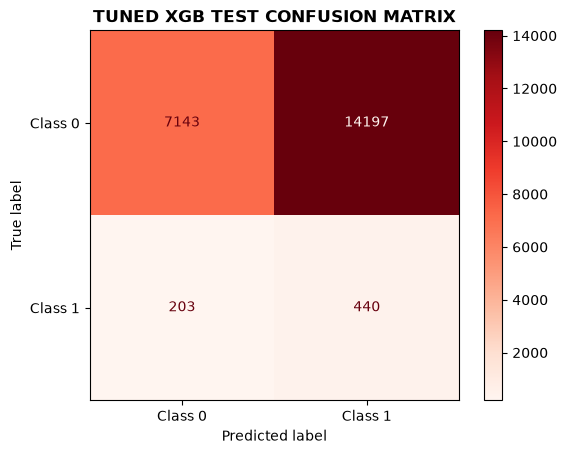

Best performing parameters are : {'model__colsample_bytree': 0.5, 'model__learning_rate': 0.01, 'model__max_depth': 4}


In [11]:
# Fixing class imbalance using SMOTE and imblearn Pipeline
# Defining the pipeline
pipeline = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', XGBClassifier(random_state=42))
])

# Define the gridsearcv parameters
params = {
    'model__max_depth': [2, 3, 4, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__colsample_bytree': [0.2, 0.3, 0.5]
}

# Defining and fitting the GridsearchCV
grid_model = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring='recall',
    n_jobs=-1,
    cv = 5
)

grid_model.fit(X_train, y_train)

# Model evaluation
#Predictions
train_preds = grid_model.predict(X_train)
test_preds = grid_model.predict(X_test)

#Evaluation
print('TUNED XGB MODEL TRAINING SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_train, train_preds))
print(f'='*100)
print('TUNED XGB MODEL TEST SUMMARY REPORT')
print(f'='*100)
print(classification_report(y_test, test_preds))

#Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Reds)
plt.title('TUNED XGB TEST CONFUSION MATRIX', weight = 'bold')
plt.show()

#Best params
print(f'Best performing parameters are : {grid_model.best_params_}')

### OPTUNA TUNING

In [12]:
# Defining objective
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 5)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.1, 0.5)

    pipeline = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', XGBClassifier(random_state=42, max_depth = max_depth,
                                    learning_rate = learning_rate, colsample_bytree = colsample_bytree))
    ])

    # cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(pipeline, X_train, y_train, cv=5, n_jobs=-1, scoring='recall')

    return score.mean()

# Creating study
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200)

#Best Params
print('BEST PARAMS')
print(f'='*100)
print(study.best_params)

[I 2026-07-20 13:56:54,105] A new study created in memory with name: no-name-f3554137-637f-4689-9b48-03d8cf9c44fd


[I 2026-07-20 13:56:56,389] Trial 0 finished with value: 0.5420173019530807 and parameters: {'max_depth': 3, 'learning_rate': 0.09556428757689246, 'colsample_bytree': 0.39279757672456206}. Best is trial 0 with value: 0.5420173019530807.
[I 2026-07-20 13:56:57,967] Trial 1 finished with value: 0.5723115862642137 and parameters: {'max_depth': 4, 'learning_rate': 0.02404167763981929, 'colsample_bytree': 0.16239780813448107}. Best is trial 1 with value: 0.5723115862642137.
[I 2026-07-20 13:56:59,809] Trial 2 finished with value: 0.5649155679800536 and parameters: {'max_depth': 2, 'learning_rate': 0.08795585311974417, 'colsample_bytree': 0.34044600469728353}. Best is trial 1 with value: 0.5723115862642137.
[I 2026-07-20 13:57:01,976] Trial 3 finished with value: 0.5664719882135166 and parameters: {'max_depth': 4, 'learning_rate': 0.011852604486622221, 'colsample_bytree': 0.4879639408647978}. Best is trial 1 with value: 0.5723115862642137.
[I 2026-07-20 13:57:03,506] Trial 4 finished with va

BEST PARAMS
{'max_depth': 5, 'learning_rate': 0.027917213360367274, 'colsample_bytree': 0.39370101282312164}


In [13]:
study.best_value

0.5882618714819993

## HYPERPARAMETER TUNING RESULTS

### GridSearchCV

**Configuration:**
- Pipeline: SMOTE → XGBClassifier
- Parameter grid: `max_depth` [2,3,4], `learning_rate` [0.01, 0.05, 0.1], `colsample_bytree` [0.2, 0.5]
- Total combinations: 18 × 5 folds = 90 models trained
- Scoring: recall
- cv: 5

**Best Parameters:**
```python
{'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
```

**Best Recall Score: 0.68**

**Comparison vs Base XGBoost:**

| Metric | Base XGBoost | GridSearchCV Tuned |
|---|---|---|
| Recall (fraud) | 0.62 | 0.68 |
| Precision (fraud) | 0.03 | 0.03 |
| F1 (fraud) | 0.06 | 0.06 |
| Accuracy | 0.41 | 0.34 |

Recall improved from 0.62 to 0.68 — the model now catches 68% of fraud cases. Precision remains at 0.03, consistent with the synthetic data limitation established during base model training. The false positive count increased alongside recall — a direct tradeoff inherent to optimising for recall on a weak-signal dataset.

---

### Optuna (Bayesian Optimisation)

Four configurations were tested to understand Optuna's behaviour on this dataset:

| Configuration | Sampler | max_depth Range | CV Strategy | Best Recall | Best max_depth |
|---|---|---|---|---|---|
| Run 1 | RandomSampler | 2–10 | Standard (cv=5) | 0.588 | 6 |
| Run 2 | TPESampler | 2–10 | Standard (cv=5) | 0.520 | 10 |
| Run 3 | TPESampler | 2–5 | StratifiedKFold | 0.520 | 5 |
| Run 4 | TPESampler | 2–5 | Standard (cv=5) | 0.588 | 5 |

**Best Optuna Result: 0.588 recall** — underperforming GridSearchCV's 0.68 across all configurations.

---

### Why GridSearchCV Outperformed Optuna

This outcome is counterintuitive — Optuna's Bayesian optimisation (TPESampler) is generally considered superior to exhaustive grid search for large, complex parameter spaces. However, on this dataset the result reverses, for three reasons:

**1. Weak signal limits the parameter landscape complexity.**
Genuine predictive signal exists in only two features — `drain_rate` and `account_emptied`. With most features being synthetic noise, there is no complex hyperparameter landscape for Optuna to navigate intelligently. GridSearchCV's narrow, well-chosen grid covered the meaningful search space exhaustively in 90 models.

**2. Optuna gravitated toward deeper trees.**
With a wide `max_depth` range (2–10), TPESampler consistently selected `max_depth=10` — the deepest available option. Deeper trees on a noisy synthetic dataset overfit to noise patterns rather than genuine fraud signal, degrading recall on the validation folds. GridSearchCV was constrained to `max_depth` [2,3,4] which kept trees shallow and noise-resistant.

**3. RandomSampler eliminated Optuna's core advantage.**
Run 1 used `RandomSampler` — pure random search with no learning between trials. This removed Bayesian optimisation entirely, reducing Optuna to 200 random guesses. GridSearchCV's systematic exhaustive search outperformed random search on a small, well-defined parameter space.

**4. StratifiedKFold with SMOTE was redundant.**
With SMOTE inside the pipeline rebalancing each fold's training data, StratifiedKFold's class preservation added an unnecessary constraint without improving performance. Standard CV inside the objective function produced equal or better results.

---

### Key Lesson

Bayesian optimisation is not universally superior to grid search. Its advantage emerges on **high-dimensional parameter spaces with genuine signal** where exhaustive search is computationally prohibitive. On weak-signal datasets with few meaningful hyperparameter interactions, a well-chosen narrow grid searched exhaustively outperforms intelligent wide-range search.

This is an empirical finding, not a theoretical one — confirmed across four Optuna configurations on this specific dataset.

---

### Selected Model for Final Evaluation

**GridSearchCV tuned XGBoost** with parameters:
```python
{'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
```

This model proceeds to final evaluation against `evaluation.csv` — 10,000 completely unseen transactions with the original 97/3 class ratio preserved, untouched until this point.

## EVALUATION AGAINST EVALUATION SET

Since the best performing model as the tuned gridsearch model with the best parameters being `{'model__colsample_bytree': 0.5, 'model__learning_rate': 0.01, 'model__max_depth': 4}`, we will now test it against the `evaluation.csv` dataset to see how it performs against completely unseen data.

In [14]:
# Saving best model
best_model = grid_model.best_estimator_

In [15]:
# Preprocessing eval_df
eval_y = eval_df['is_fraud']
eval_x = eval_df.drop(columns = ['is_fraud'])

# Encoding
eval_x['device_type'] = eval_df['device_type'].map({'smartphone': 0, 'feature': 1})
eval_x_encoded = encoder.transform(eval_x)

#Predicting
eval_preds = best_model.predict(eval_x_encoded)

#Performance Monitoring
print('BEST MODEL PERFORMANCE SUMMARY ON UNSEEN DATA')
print(f'='*100)
print(classification_report(eval_y, eval_preds))

BEST MODEL PERFORMANCE SUMMARY ON UNSEEN DATA
              precision    recall  f1-score   support

           0       0.97      0.34      0.50      9707
           1       0.03      0.68      0.06       293

    accuracy                           0.35     10000
   macro avg       0.50      0.51      0.28     10000
weighted avg       0.94      0.35      0.49     10000



## FINAL EVALUATION — UNSEEN DATA

### Evaluation Dataset
The final evaluation was performed against `evaluation.csv` — 10,000 transactions carved out before any modelling began, with the original 97/3 class ratio preserved via stratification. This dataset was untouched throughout the entire training, tuning, and model selection process, making it the most honest measure of real-world performance.

| Class | Count | Ratio |
|---|---|---|
| Legitimate (0) | 9,707 | 97.07% |
| Fraud (1) | 293 | 2.93% |

---

### Results

| Metric | GridSearchCV Test Set | Unseen Eval Set |
|---|---|---|
| Recall (fraud) | 0.68 | 0.68 |
| Precision (fraud) | 0.03 | 0.03 |
| F1 (fraud) | 0.06 | 0.06 |
| Accuracy | 0.34 | 0.35 |

---

### Interpretation

**Recall held at 0.68 on completely unseen data** — the model caught 68% of fraud cases on transactions it had never seen, matching its cross-validated performance exactly. This confirms the model generalises rather than memorising training patterns.

Precision remains at 0.03 — consistent with every model and tuning configuration tested throughout this project. This is not a generalisation failure. It is a direct consequence of the synthetic dataset's uniform fraud distribution, where the only genuine predictive signal exists in `drain_rate` and `account_emptied`. Every model architecture and tuning approach converged to the same precision ceiling, confirming this is a data limitation rather than a modelling one.

---

### Full Model Comparison — All Stages

| Model | Recall (fraud) | Precision (fraud) | F1 (fraud) | Accuracy |
|---|---|---|---|---|
| Logistic Regression | 0.47 | 0.03 | 0.05 | 0.52 |
| Random Forest | 0.54 | 0.03 | 0.06 | 0.47 |
| XGBoost (base) | 0.62 | 0.03 | 0.06 | 0.41 |
| LightGBM (base) | 0.62 | 0.03 | 0.06 | 0.41 |
| XGBoost (GridSearchCV) | 0.68 | 0.03 | 0.06 | 0.34 |
| **XGBoost (eval set)** | **0.68** | **0.03** | **0.06** | **0.35** |

---

## MODEL CARD

### Model Overview

| Attribute | Detail |
|---|---|
| **Model type** | XGBoost Classifier |
| **Task** | Binary fraud classification |
| **Training data** | 87,932 transactions (80% of training.csv) |
| **Test data** | 21,983 transactions (20% of training.csv) |
| **Final evaluation** | 10,000 unseen transactions (evaluation.csv) |
| **Best parameters** | max_depth=4, learning_rate=0.01, colsample_bytree=0.5 |
| **Class imbalance handling** | SMOTE inside imblearn Pipeline (training folds only) |

---

### Performance Metrics

| Metric | Value |
|---|---|
| Recall (fraud) | 0.68 |
| Precision (fraud) | 0.03 |
| F1 score (fraud) | 0.06 |
| AUC-ROC | — |
| Accuracy | 0.35 |

> Accuracy is not a meaningful metric for this model — a naive classifier predicting all transactions as legitimate achieves 97% accuracy while catching zero fraud.

---

### Features Used

| Feature | Type | Source |
|---|---|---|
| `amount` | float | Raw |
| `sender_balance_before` | float | Raw |
| `transaction_type` | one-hot encoded | Raw → Encoded |
| `region` | one-hot encoded | Raw → Encoded |
| `device_type` | binary (0/1) | Raw → Mapped |
| `hour_sin`, `hour_cos` | float | Engineered — cyclic encoding |
| `day_sin`, `day_cos` | float | Engineered — cyclic encoding |
| `month_2026_sin`, `month_2026_cos` | float | Engineered — cyclic encoding |
| `drain_rate` | float | Engineered — `(amount / sender_balance_before) × 100` |
| `account_emptied` | binary (0/1) | Engineered — `amount >= sender_balance_before` |

**Features excluded (data leakage or unavailable at prediction time):**
- `sender_balance_after` — only available post-settlement
- `receiver_balance_before` — not accessible to sender's system at initiation
- `receiver_balance_after` — only available post-settlement
- `transaction_id` — identifier, no predictive value
- `transaction_status` — direct encoding of target variable (leakage)
- `day_of_week` — replaced by cyclic encoded `day_sin`, `day_cos`
- `hour`, `month_2026` — replaced by cyclic encoded equivalents

---

### Decisioning Logic

The model does not operate as a standalone fraud label predictor. It sits between transaction initiation and transaction completion, returning one of three decisions:

| Decision | Condition | Mechanism |
|---|---|---|
| `BLOCK` | `account_emptied = 1` | Hard rule — no model inference required |
| `BLOCK` | `drain_rate > 100%` | Hard rule — transaction exceeds available balance |
| `CHALLENGE` | Model fraud probability ≥ threshold | OTP or user verification triggered |
| `ALLOW` | Model fraud probability < threshold | Transaction proceeds normally |

Hard rules execute before the model is called. A transaction that empties the sender's account is blocked deterministically — no probability score needed.

---

### Known Limitations

**1. Synthetic data ceiling**

The dataset was synthetically generated with a near-uniform fraud distribution across all categorical variables. Fraud rate is approximately 2.93% regardless of region, device type, transaction type, hour, or day. As a result, the model's only genuine predictive signal comes from `drain_rate` and `account_emptied`. Precision is stuck at 0.03 across all model architectures and tuning configurations — this is a data limitation, not a modelling failure.

**2. Synthetic-on-synthetic augmentation**

SMOTE generates synthetic fraud samples by interpolating between existing fraud cases. Since the underlying data is itself synthetic, SMOTE amplifies existing distributional artifacts rather than learning from real fraud behaviour. Performance metrics on this dataset likely overestimate what is achievable on real M-Pesa transaction data.

**3. Missing fraud vectors**

The dataset does not capture several documented M-Pesa fraud patterns:
- SIM swap fraud is not explicitly labelled as a transaction subtype
- Agent float abuse is not represented
- Number masking and fake balance SMS traps have no corresponding features

**4. Static model**

Fraud patterns evolve as fraudsters adapt their tactics. This model was trained on a fixed synthetic dataset and has no mechanism for online learning or periodic retraining. In production, model performance should be monitored continuously and the model retrained as new labelled fraud data becomes available.

**5. Temporal scope**

The dataset covers 2026 transaction patterns only. Seasonal effects, economic conditions, and platform changes that influence fraud behaviour are not captured.

---

### Intended Use

This model is intended as a **real-time transaction decisioning engine** for M-Pesa-style mobile money platforms. It is designed to intercept transactions before settlement and return an `ALLOW`, `CHALLENGE`, or `BLOCK` decision within the latency window of a transaction initiation.

**Not intended for:**
- Post-transaction fraud auditing
- Investigation or prosecution evidence
- Risk scoring of users rather than individual transactions

---

### Future Work

- Retrain on real M-Pesa transaction data with genuine behavioural signal across categorical features
- Add SIM swap flag, agent transaction type, and network velocity features
- Extend to bank transaction channel with a `channel` feature distinguishing mobile money from bank transfers
- Implement online learning for continuous model adaptation as fraud patterns evolve
- Build a full preprocessing pipeline (raw input → engineered features → encoded → prediction) for clean FastAPI deployment

## MODEL AND ENCODER SAVING

In [16]:
# Saving best model
joblib.dump(best_model, '../models/best_model.pkl')

# Saving the encoder
joblib.dump(encoder, '../models/encoder.pkl')

['../models/encoder.pkl']

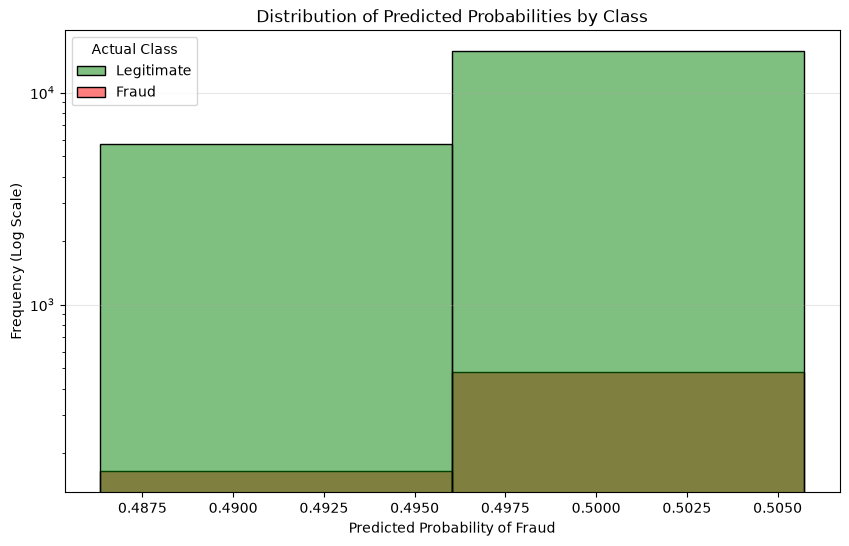

In [ ]:
# 1. Get predicted probabilities
probs = grid_model.best_estimator_.predict_proba(X_test)[:, 1]

# 2. Combine into a clean DataFrame for Seaborn
df_plot = pd.DataFrame({"Probability": probs, "Actual Class": y_test})

# Map labels for clear legend presentation
df_plot["Actual Class"] = df_plot["Actual Class"].map(
    {1: "Fraud", 0: "Legitimate"}
)

# 3. Create the Seaborn histogram
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_plot,
    x="Probability",
    hue="Actual Class",
    stat="count",
    common_norm=False,
    bins=2,
    palette={"Legitimate": "green", "Fraud": "red"},
    alpha=0.5,
)

plt.yscale("log")  # Keeps the minor fraud distribution visible
plt.title("Distribution of Predicted Probabilities by Class")
plt.xlabel("Predicted Probability of Fraud")
plt.ylabel("Frequency (Log Scale)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Probability Threshold Calibration

After training, predicted probabilities were inspected on the test set to determine appropriate 
`ALLOW / CHALLENGE / BLOCK` thresholds before finalising the FastAPI endpoint.

**Finding:** The model outputs probabilities within an extremely narrow range of **0.487 – 0.506**, 
with both legitimate and fraudulent transactions clustering in the same window. The model lacks 
confident separation between classes in probability space — a direct consequence of the synthetic 
dataset's uniform fraud distribution and limited genuine signal.

This means standard probability thresholds (e.g. 0.6 for CHALLENGE, 0.9 for BLOCK) would never 
trigger — every transaction would be classified as ALLOW regardless of actual fraud risk.

**Thresholds adjusted to reflect actual model output range:**

| Threshold | Action | Rationale |
|---|---|---|
| `probability >= 0.502` | `BLOCK` | Upper range of model output — highest relative fraud signal |
| `probability >= 0.497` | `CHALLENGE` | Mid range — elevated but uncertain risk |
| `probability < 0.497` | `ALLOW` | Lower range — lowest relative fraud signal |

**Important:** Given the model's narrow probability range, the hard rules carry more 
discriminative weight than the probability scores in practice:

- `account_emptied = 1` → immediate `BLOCK` before model is called
- `drain_rate > 100%` → immediate `BLOCK` before model is called

These deterministic signals are evaluated first in the prediction pipeline, 
reserving model inference for transactions that pass the hard rule checks.

> This threshold calibration should be revisited when the model is retrained on real 
> M-Pesa transaction data, where probability scores are expected to be more spread and 
> meaningful as genuine fraud signal emerges across categorical features.